In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import random, os, json, time
from collections import Counter

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyTorch: {torch.__version__}')
# I am setting up the development environment by importing necessary libraries, configuring random seeds for reproducibility, and identifying the compute device.

Device : cuda
PyTorch: 2.10.0+cu128


In [ ]:
with open('TrainingNames.txt', 'r') as f:
    all_names = [line.strip().lower() for line in f if line.strip()]

print(f'Total names : {len(all_names)}')
print(f'Samples     : {[n.capitalize() for n in all_names[:12]]}')

SOS, EOS, PAD = '<', '>', '~'
unique_chars = sorted(set(''.join(all_names)))
vocab    = [PAD, SOS, EOS] + unique_chars
char2idx = {ch: i for i, ch in enumerate(vocab)}
idx2char = {i: ch for ch, i in char2idx.items()}

VOCAB_SIZE = len(vocab)
PAD_IDX    = char2idx[PAD]
SOS_IDX    = char2idx[SOS]
EOS_IDX    = char2idx[EOS]

print(f'\nVocab size  : {VOCAB_SIZE}')
print(f'Characters  : {vocab}')
# I am loading and preprocessing the dataset here. This involves reading names from a file, creating a unique vocabulary of characters, and defining special tokens for sequence handling.

Total names : 1000
Samples     : ['Aarav', 'Aditya', 'Akash', 'Akshay', 'Amit', 'Amitabh', 'Anand', 'Aniket', 'Anil', 'Anish', 'Ankit', 'Ankur']

Vocab size  : 29
Characters  : ['~', '<', '>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


Min / Mean / Max length: 2 / 7.3 / 18
MAX_LEN (incl. SOS+EOS): 20


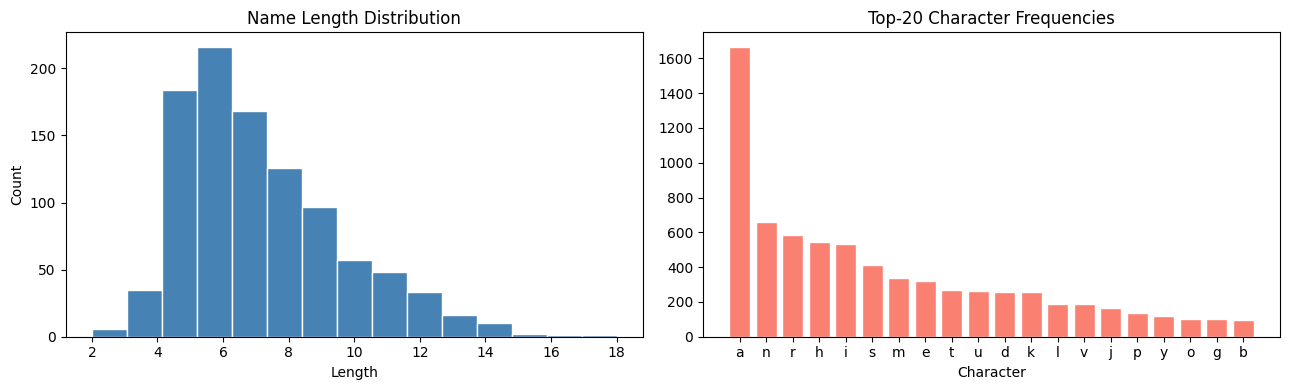

In [ ]:
name_lengths = [len(n) for n in all_names]
MAX_LEN = max(name_lengths) + 2   # +2 for SOS + EOS
print(f'Min / Mean / Max length: {min(name_lengths)} / {np.mean(name_lengths):.1f} / {max(name_lengths)}')
print(f'MAX_LEN (incl. SOS+EOS): {MAX_LEN}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(name_lengths, bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Name Length Distribution')
axes[0].set_xlabel('Length'); axes[0].set_ylabel('Count')

char_freq = Counter(''.join(all_names))
chars, freqs = zip(*char_freq.most_common(20))
axes[1].bar(chars, freqs, color='salmon', edgecolor='white')
axes[1].set_title('Top-20 Character Frequencies')
axes[1].set_xlabel('Character')

plt.tight_layout()
plt.savefig('dataset_stats.png', dpi=150, bbox_inches='tight')
plt.show()
# Here, I am analyzing the statistical properties of the dataset, such as name lengths and character frequencies, and visualizing them to gain insights into the data distribution.

In [ ]:
def encode_name(name):
    return [SOS_IDX] + [char2idx[c] for c in name] + [EOS_IDX]

def decode_indices(indices):
    chars = []
    for idx in indices:
        if idx == EOS_IDX: break
        if idx in (SOS_IDX, PAD_IDX): continue
        chars.append(idx2char[idx])
    return ''.join(chars)

class NameDataset(Dataset):
    def __init__(self, names, max_len):
        self.seqs = []
        for name in names:
            enc = encode_name(name)
            enc = enc + [PAD_IDX] * (max_len - len(enc))
            self.seqs.append(enc[:max_len])

    def __len__(self): return len(self.seqs)
    def __getitem__(self, i):
        seq = torch.tensor(self.seqs[i], dtype=torch.long)
        return seq[:-1], seq[1:]   # inp = SOS…last_char, tgt = first_char…EOS

dataset    = NameDataset(all_names, MAX_LEN)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=False)

inp_s, tgt_s = dataset[0]
print('Encoded input :', inp_s[:8].tolist())
print('Decoded name  :', decode_indices(inp_s.tolist()))
# I am defining utility functions to convert names to numerical sequences and vice versa, and setting up a custom PyTorch Dataset and DataLoader to manage the data for model training.

Encoded input : [1, 3, 3, 20, 3, 24, 2, 0]
Decoded name  : aarav


In [ ]:
class VanillaRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.W_xh = nn.Linear(input_size,  hidden_size, bias=False)
        self.W_hh = nn.Linear(hidden_size, hidden_size, bias=True)
        nn.init.orthogonal_(self.W_hh.weight)   # improves gradient flow

    def forward(self, x, h):
        return torch.tanh(self.W_xh(x) + self.W_hh(h))


class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embed_size=64, hidden_size=256,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.embedding   = nn.Embedding(vocab_size, embed_size, padding_idx=pad_idx)
        self.dropout     = nn.Dropout(dropout)
        self.cells = nn.ModuleList()
        for l in range(num_layers):
            self.cells.append(VanillaRNNCell(embed_size if l == 0 else hidden_size, hidden_size))
        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        B, T = x.shape
        emb = self.dropout(self.embedding(x))
        if hidden is None:
            hidden = [torch.zeros(B, self.hidden_size, device=x.device)
                      for _ in range(self.num_layers)]
        outputs = []
        for t in range(T):
            inp = emb[:, t, :]
            for l, cell in enumerate(self.cells):
                hidden[l] = cell(inp, hidden[l])
                inp = self.dropout(hidden[l])
            outputs.append(inp)
        logits = self.fc_out(torch.stack(outputs, 1))
        return logits, hidden

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


vanilla_rnn = VanillaRNN(VOCAB_SIZE, 64, 256, 2, 0.3, PAD_IDX).to(device)
print(f'Vanilla RNN  params: {vanilla_rnn.count_parameters():,}')
# I am implementing the foundational `VanillaRNNCell` and `VanillaRNN` model, which serves as our baseline. This model processes sequences character by character, learning to predict the next character in a name.

Vanilla RNN  params: 222,813


In [ ]:
class ImprovedBLSTM(nn.Module):
    """
    Hyperparameters
    ---------------
    embed_size  = 64
    hidden_size = 512   (each direction)
    num_layers  = 3
    dropout     = 0.35
    aux_weight  = 0.3
    """
    AUX_WEIGHT = 0.30

    def __init__(self, vocab_size, embed_size=64, hidden_size=512,
                 num_layers=3, dropout=0.35, pad_idx=0):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_idx)
        self.drop       = nn.Dropout(dropout)

        lstm_kw = dict(input_size=embed_size, hidden_size=hidden_size,
                       num_layers=num_layers, batch_first=True,
                       dropout=dropout if num_layers > 1 else 0.0)

        self.fwd_lstm = nn.LSTM(**lstm_kw)   # left → right  (generation path)
        self.bwd_lstm = nn.LSTM(**lstm_kw)   # right → left  (auxiliary training)

        self.ln_fwd = nn.LayerNorm(hidden_size)
        self.ln_bwd = nn.LayerNorm(hidden_size)

        # Primary generation head — trained only on fwd hidden states
        self.fc_out = nn.Linear(hidden_size, vocab_size)
        # Auxiliary backward head — training only; never used during generation
        self.fc_bwd = nn.Linear(hidden_size, vocab_size)

        self._init_weights()

    def _init_weights(self):
        for lstm in (self.fwd_lstm, self.bwd_lstm):
            for name, p in lstm.named_parameters():
                if 'weight_ih' in name: nn.init.xavier_uniform_(p)
                elif 'weight_hh' in name: nn.init.orthogonal_(p)
                elif 'bias' in name: nn.init.zeros_(p)

        for lstm in (self.fwd_lstm, self.bwd_lstm):
            for names in lstm._all_weights:
                for name in filter(lambda n: 'bias' in n, names):
                    bias = getattr(lstm, name)
                    n   = bias.size(0)
                    bias.data[n // 4 : n // 2].fill_(1.0)

    def forward(self, x, hidden=None):
        emb = self.drop(self.embedding(x))               # (B, T, E)


        fwd_out, fwd_h = self.fwd_lstm(emb, hidden)      # (B, T, H)
        fwd_out        = self.ln_fwd(fwd_out)
        logits_fwd     = self.fc_out(self.drop(fwd_out)) # (B, T, V)

        logits_bwd = None
        if self.training:
            emb_rev    = torch.flip(emb, dims=[1])
            bwd_out, _ = self.bwd_lstm(emb_rev)
            bwd_out    = torch.flip(self.ln_bwd(bwd_out), dims=[1])
            logits_bwd = self.fc_bwd(self.drop(bwd_out)) # (B, T, V)

        return logits_fwd, fwd_h, logits_bwd

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


blstm_model = ImprovedBLSTM(VOCAB_SIZE, 64, 512, 3, 0.35, PAD_IDX).to(device)
print(f'Improved BiLSTM params : {blstm_model.count_parameters():,}')
print('  embed=64 | hidden=512 (per direction) | layers=3 | dropout=0.35')
print('  Generation path: fwd_lstm → ln_fwd → fc_out  (never uses bwd_lstm)')
# I am implementing the `ImprovedBLSTM` model, which utilizes separate forward and backward LSTMs to improve learning by incorporating both past and future context during training, while maintaining a consistent generation path.

Improved BiLSTM params : 10,806,138
  embed=64 | hidden=512 (per direction) | layers=3 | dropout=0.35
  Generation path: fwd_lstm → ln_fwd → fc_out  (never uses bwd_lstm)


In [ ]:
class CausalHistoryAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.W_q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_k = nn.Linear(hidden_size, hidden_size, bias=False)
        self.v   = nn.Linear(hidden_size, 1,           bias=False)

    def forward(self, query, keys):
        energy  = torch.tanh(self.W_q(query) + self.W_k(keys))  # (B, t, H)
        scores  = self.v(energy).transpose(1, 2)                 # (B, 1, t)
        weights = F.softmax(scores, dim=-1)                      # (B, 1, t)
        context = torch.bmm(weights, keys)                       # (B, 1, H)
        return context, weights


class RNNCausalAttention(nn.Module):
    """

    Hyperparameters
    ---------------
    embed_size  = 64
    hidden_size = 512
    num_layers  = 3
    dropout     = 0.35
    """

    def __init__(self, vocab_size, embed_size=64, hidden_size=512,
                 num_layers=3, dropout=0.35, pad_idx=0):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_idx)
        self.drop       = nn.Dropout(dropout)


        self.rnn = nn.RNN(
            input_size  = embed_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            nonlinearity = 'tanh',
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        self.ln_rnn = nn.LayerNorm(hidden_size)
        self.ln_out = nn.LayerNorm(hidden_size)

        self.attention = CausalHistoryAttention(hidden_size)

        self.ctx_gate = nn.Linear(hidden_size * 2, hidden_size)

        self.fc_out = nn.Linear(hidden_size, vocab_size)
        self._init_weights()

    def _init_weights(self):
        for name, p in self.rnn.named_parameters():
            if 'weight_ih' in name: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name: nn.init.orthogonal_(p)
            elif 'bias' in name: nn.init.zeros_(p)


    def _merge(self, h_t, past):
        if past.shape[1] == 0:
            ctx = torch.zeros_like(h_t)                          # no history yet
        else:
            ctx, _ = self.attention(h_t, past)                   # (B, 1, H)
        combined = torch.cat([h_t.squeeze(1), ctx.squeeze(1)], dim=-1)  # (B, 2H)
        merged   = torch.tanh(self.ctx_gate(combined)).unsqueeze(1)     # (B, 1, H)
        return merged + h_t                                              # gated residual


    def forward(self, x, hidden=None, key_cache=None):
        B, T = x.shape
        emb = self.drop(self.embedding(x))             # (B, T, E)

        rnn_out, new_h = self.rnn(emb, hidden)         # (B, T, H)
        rnn_out = self.ln_rnn(rnn_out)

        outputs = []
        for t in range(T):
            h_t = rnn_out[:, t : t+1, :]               # (B, 1, H)

            if key_cache is not None:
                if len(key_cache) > 0:
                    past = torch.stack(key_cache, dim=1)   # (B, t, H)
                else:
                    past = torch.zeros(B, 0, self.hidden_size, device=x.device)
                merged = self._merge(h_t, past)
                key_cache.append(rnn_out[:, t, :].detach())
            else:
                if t == 0:
                    past = torch.zeros(B, 0, self.hidden_size, device=x.device)
                else:
                    past = rnn_out[:, :t, :]              # (B, t, H)
                merged = self._merge(h_t, past)

            outputs.append(merged.squeeze(1))            # (B, H)

        out    = torch.stack(outputs, dim=1)             # (B, T, H)
        out    = self.ln_out(out)
        logits = self.fc_out(self.drop(out))             # (B, T, V)
        return logits, new_h, key_cache

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


attn_rnn = RNNCausalAttention(VOCAB_SIZE, 64, 512, 3, 0.35, PAD_IDX).to(device)
print(f'RNN + Causal Attention params : {attn_rnn.count_parameters():,}')
print('  embed=64 | hidden=512 | layers=3 | dropout=0.35 | nonlinearity=tanh')
print('  Training == Generation (causal mask vs. growing cache — same logic)')
# I am defining a `CausalHistoryAttention` mechanism and integrating it into an `RNNCausalAttention` model. This allows the model to selectively focus on relevant past information when generating the next character, enhancing its predictive capability.

RNN + Causal Attention params : 2,414,941
  embed=64 | hidden=512 | layers=3 | dropout=0.35 | nonlinearity=tanh
  Training == Generation (causal mask vs. growing cache — same logic)


──────────────────────────────────────────
Vanilla RNN               :    222,813
Improved BiLSTM           : 10,806,138
RNN + Causal Attention    :  2,414,941


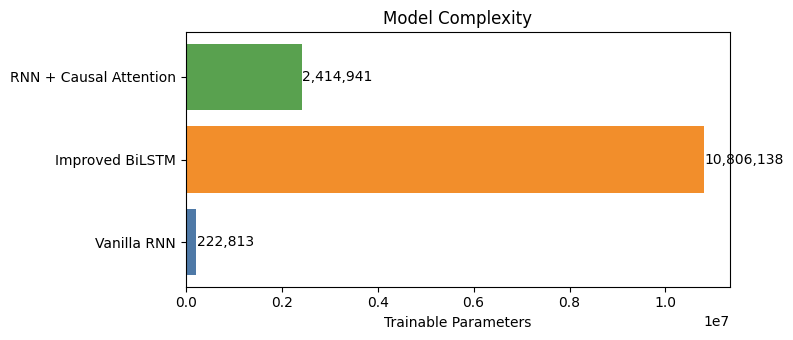

In [ ]:
# ── Parameter Summary ────────────────────────────────────────────────────────
params = {
    'Vanilla RNN'           : vanilla_rnn.count_parameters(),
    'Improved BiLSTM'       : blstm_model.count_parameters(),
    'RNN + Causal Attention': attn_rnn.count_parameters(),
}
print('─' * 42)
for k, v in params.items():
    print(f'{k:<26}: {v:>10,}')

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ['#4e79a7', '#f28e2b', '#59a14f']
bars = ax.barh(list(params.keys()), list(params.values()), color=colors)
for bar in bars:
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():,}', va='center')
ax.set_xlabel('Trainable Parameters')
ax.set_title('Model Complexity')
plt.tight_layout()
plt.savefig('param_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
# I am generating a comparative plot to visually represent the number of trainable parameters for each implemented model, providing an overview of their complexity.

## 3. Training

In [ ]:
class LabelSmoothingLoss(nn.Module):
    def __init__(self, vocab_size, pad_idx, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.pad_idx   = pad_idx
        self.vocab_size = vocab_size

    def forward(self, logits, target):
        # logits : (N, V), target : (N,)
        log_prob = F.log_softmax(logits, dim=-1)
        smooth   = self.smoothing / (self.vocab_size - 2)   # uniform over non-PAD chars
        with torch.no_grad():
            dist = torch.full_like(log_prob, smooth)
            dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
            dist[:, self.pad_idx] = 0.0
        loss = -(dist * log_prob).sum(dim=-1)
        mask = (target != self.pad_idx)
        return loss[mask].mean()


def train_vanilla_rnn(model, dataloader, epochs, lr, clip=5.0):
    criterion = LabelSmoothingLoss(VOCAB_SIZE, PAD_IDX, smoothing=0.10)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr/20)

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        total = 0.0
        for inp, tgt in dataloader:
            inp, tgt = inp.to(device), tgt.to(device)
            optimizer.zero_grad()
            logits, _ = model(inp)
            loss = criterion(logits.view(-1, VOCAB_SIZE), tgt.view(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            total += loss.item()
        avg = total / len(dataloader)
        history.append(avg)
        scheduler.step()
        if epoch % 10 == 0 or epoch == 1:
            print(f'[VanillaRNN] Ep {epoch:>3}/{epochs}  loss={avg:.4f}  lr={scheduler.get_last_lr()[0]:.5f}')
    return history


def train_blstm(model, dataloader, epochs, lr, clip=5.0):
    criterion = LabelSmoothingLoss(VOCAB_SIZE, PAD_IDX, smoothing=0.10)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr/20)

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        total = 0.0
        for inp, tgt in dataloader:
            inp, tgt = inp.to(device), tgt.to(device)
            optimizer.zero_grad()

            logits_fwd, _, logits_bwd = model(inp)          # bwd_logits ≠ None during training

            # Primary forward loss
            loss_fwd = criterion(logits_fwd.view(-1, VOCAB_SIZE), tgt.view(-1))

            # Auxiliary backward loss: backward LSTM predicts reversed target
            tgt_rev  = torch.flip(tgt, dims=[1])
            loss_bwd = criterion(logits_bwd.view(-1, VOCAB_SIZE), tgt_rev.view(-1))

            loss = loss_fwd + model.AUX_WEIGHT * loss_bwd
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            total += loss_fwd.item()   # track primary loss for comparison

        avg = total / len(dataloader)
        history.append(avg)
        scheduler.step()
        if epoch % 10 == 0 or epoch == 1:
            print(f'[BiLSTM]     Ep {epoch:>3}/{epochs}  fwd_loss={avg:.4f}  lr={scheduler.get_last_lr()[0]:.5f}')
    return history


def train_rnn_attn(model, dataloader, epochs, lr, clip=5.0):
    criterion = LabelSmoothingLoss(VOCAB_SIZE, PAD_IDX, smoothing=0.10)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr/20)

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        total = 0.0
        for inp, tgt in dataloader:
            inp, tgt = inp.to(device), tgt.to(device)
            optimizer.zero_grad()
            logits, _, _ = model(inp)          # key_cache=None → training mode (causal mask)
            loss = criterion(logits.view(-1, VOCAB_SIZE), tgt.view(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            total += loss.item()
        avg = total / len(dataloader)
        history.append(avg)
        scheduler.step()
        if epoch % 10 == 0 or epoch == 1:
            print(f'[RNN+Attn]   Ep {epoch:>3}/{epochs}  loss={avg:.4f}  lr={scheduler.get_last_lr()[0]:.5f}')
    return history


EPOCHS = 100
LR     = 8e-4
print(f'Epochs={EPOCHS}  LR={LR}  Batch={dataloader.batch_size}  Clip=5.0')
# I am defining the `LabelSmoothingLoss` function, which helps prevent models from becoming overconfident during training, and then setting up individual training loops for the Vanilla RNN, Improved BiLSTM, and RNN with Causal Attention models. I am also initializing global training parameters like the number of epochs and learning rate.

Epochs=100  LR=0.0008  Batch=64  Clip=5.0


In [ ]:
print('=' * 50)
print('Training Vanilla RNN (baseline)')
print('=' * 50)
t0 = time.time()
history_rnn = train_vanilla_rnn(vanilla_rnn, dataloader, EPOCHS, LR)
print(f'Done in {time.time()-t0:.0f}s  |  final loss = {history_rnn[-1]:.4f}')
# I am initiating the training for the Vanilla RNN model and monitoring its progress by tracking the loss over epochs and measuring the total training time.

Training Vanilla RNN (baseline)
[VanillaRNN] Ep   1/100  loss=2.9172  lr=0.00080
[VanillaRNN] Ep  10/100  loss=2.3004  lr=0.00078
[VanillaRNN] Ep  20/100  loss=2.1917  lr=0.00073
[VanillaRNN] Ep  30/100  loss=2.1002  lr=0.00064
[VanillaRNN] Ep  40/100  loss=2.0401  lr=0.00054
[VanillaRNN] Ep  50/100  loss=1.9932  lr=0.00042
[VanillaRNN] Ep  60/100  loss=1.9492  lr=0.00030
[VanillaRNN] Ep  70/100  loss=1.9332  lr=0.00020
[VanillaRNN] Ep  80/100  loss=1.9117  lr=0.00011
[VanillaRNN] Ep  90/100  loss=1.8936  lr=0.00006
[VanillaRNN] Ep 100/100  loss=1.9032  lr=0.00004
Done in 38s  |  final loss = 1.9032


In [ ]:
print('=' * 50)
print('Training Improved BiLSTM')
print('=' * 50)
t0 = time.time()
history_blstm = train_blstm(blstm_model, dataloader, EPOCHS, LR)
print(f'Done in {time.time()-t0:.0f}s  |  final fwd loss = {history_blstm[-1]:.4f}')
# I am beginning the training phase for the Improved BiLSTM model, observing its performance through the forward loss and noting the duration of the training process.

Training Improved BiLSTM
[BiLSTM]     Ep   1/100  fwd_loss=3.0767  lr=0.00080
[BiLSTM]     Ep  10/100  fwd_loss=2.4002  lr=0.00078
[BiLSTM]     Ep  20/100  fwd_loss=2.0909  lr=0.00073
[BiLSTM]     Ep  30/100  fwd_loss=1.8455  lr=0.00064
[BiLSTM]     Ep  40/100  fwd_loss=1.7094  lr=0.00054
[BiLSTM]     Ep  50/100  fwd_loss=1.6042  lr=0.00042
[BiLSTM]     Ep  60/100  fwd_loss=1.5629  lr=0.00030
[BiLSTM]     Ep  70/100  fwd_loss=1.5370  lr=0.00020
[BiLSTM]     Ep  80/100  fwd_loss=1.5230  lr=0.00011
[BiLSTM]     Ep  90/100  fwd_loss=1.5142  lr=0.00006
[BiLSTM]     Ep 100/100  fwd_loss=1.5071  lr=0.00004
Done in 50s  |  final fwd loss = 1.5071


In [ ]:
print('=' * 50)
print('Training RNN + Causal History Attention')
print('=' * 50)
t0 = time.time()
history_attn = train_rnn_attn(attn_rnn, dataloader, EPOCHS, LR)
print(f'Done in {time.time()-t0:.0f}s  |  final loss = {history_attn[-1]:.4f}')
# I am starting the training for the RNN with Causal History Attention model, evaluating its loss performance throughout the epochs, and recording the total time taken for training.

Training RNN + Causal History Attention
[RNN+Attn]   Ep   1/100  loss=2.8699  lr=0.00080
[RNN+Attn]   Ep  10/100  loss=2.2854  lr=0.00078
[RNN+Attn]   Ep  20/100  loss=2.0941  lr=0.00073
[RNN+Attn]   Ep  30/100  loss=1.9330  lr=0.00064
[RNN+Attn]   Ep  40/100  loss=1.8228  lr=0.00054
[RNN+Attn]   Ep  50/100  loss=1.7057  lr=0.00042
[RNN+Attn]   Ep  60/100  loss=1.6551  lr=0.00030
[RNN+Attn]   Ep  70/100  loss=1.6092  lr=0.00020
[RNN+Attn]   Ep  80/100  loss=1.5834  lr=0.00011
[RNN+Attn]   Ep  90/100  loss=1.5730  lr=0.00006
[RNN+Attn]   Ep 100/100  loss=1.5503  lr=0.00004
Done in 47s  |  final loss = 1.5503


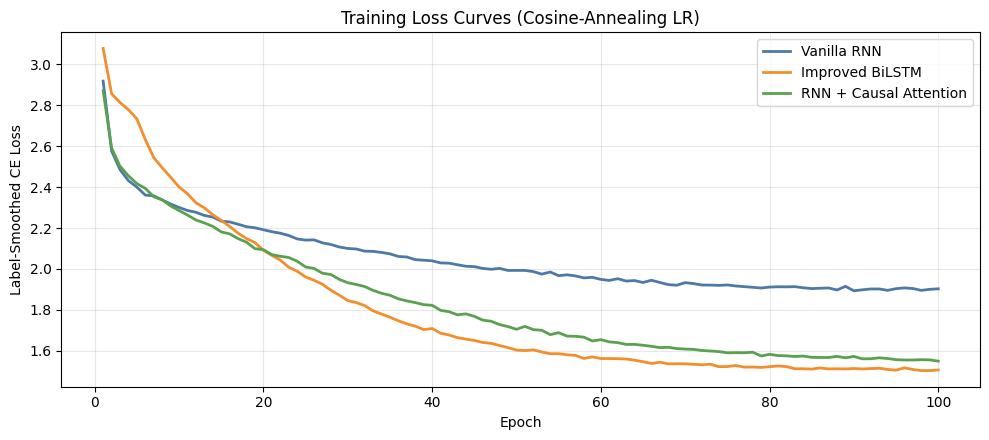

In [ ]:
plt.figure(figsize=(10, 4.5))
x = range(1, EPOCHS + 1)
plt.plot(x, history_rnn,   label='Vanilla RNN',               color='#4e79a7', lw=2)
plt.plot(x, history_blstm, label='Improved BiLSTM',           color='#f28e2b', lw=2)
plt.plot(x, history_attn,  label='RNN + Causal Attention',    color='#59a14f', lw=2)
plt.xlabel('Epoch'); plt.ylabel('Label-Smoothed CE Loss')
plt.title('Training Loss Curves (Cosine-Annealing LR)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
# I am visualizing the training loss curves for all three models over the training epochs. This plot helps compare their learning progression and convergence behavior.

In [ ]:
def top_p_sample(logits, p=0.90):
    probs   = F.softmax(logits, dim=-1)
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cum_probs = torch.cumsum(sorted_probs, dim=-1)
    # Remove tokens beyond the nucleus
    remove = cum_probs - sorted_probs > p
    sorted_probs[remove] = 0.0
    sorted_probs = sorted_probs / sorted_probs.sum()   # renormalise
    chosen = torch.multinomial(sorted_probs, num_samples=1)
    return sorted_idx[chosen].item()


@torch.no_grad()
def generate_name(model, max_len=20, temperature=0.85, top_p=0.92):
    model.eval()
    generated = [SOS_IDX]
    hidden    = None

    for _ in range(max_len):
        x = torch.tensor([[generated[-1]]], device=device)
        out = model(x, hidden)
        logits, hidden = out[0], out[1]    # works for 2-tuple and 3-tuple
        logit = logits[:, -1, :].squeeze(0) / temperature
        next_idx = top_p_sample(logit, top_p)
        if next_idx == EOS_IDX: break
        generated.append(next_idx)

    return decode_indices(generated)


# ── Generator for RNNCausalAttention (uses key_cache) ─────────────────────────
@torch.no_grad()
def generate_name_attn(model, max_len=20, temperature=0.85, top_p=0.92):
    model.eval()
    generated = [SOS_IDX]
    hidden    = None
    key_cache = []   # grows by 1 at each step

    for _ in range(max_len):
        x = torch.tensor([[generated[-1]]], device=device)
        logits, hidden, key_cache = model(x, hidden, key_cache)
        logit = logits[:, -1, :].squeeze(0) / temperature
        next_idx = top_p_sample(logit, top_p)
        if next_idx == EOS_IDX: break
        generated.append(next_idx)

    return decode_indices(generated)


def bulk_generate(model, n, temperature=0.85, top_p=0.92, is_attn=False):
    gen_fn = generate_name_attn if is_attn else generate_name
    names  = []
    while len(names) < n:
        name = gen_fn(model, temperature=temperature, top_p=top_p)
        if len(name) >= 3:
            names.append(name.capitalize())
    return names


N_GEN = 200
T, P  = 0.85, 0.92

gen_rnn   = bulk_generate(vanilla_rnn, N_GEN, T, P, is_attn=False)
gen_blstm = bulk_generate(blstm_model, N_GEN, T, P, is_attn=False)
gen_attn  = bulk_generate(attn_rnn,   N_GEN, T, P, is_attn=True)

print('\n=== Sample Generated Names ===')
for label, names in [('Vanilla RNN',           gen_rnn),
                     ('Improved BiLSTM',        gen_blstm),
                     ('RNN + Causal Attention', gen_attn)]:
    print(f'\n{label}:')
    print('  ' + ',  '.join(names[:20]))
# I am defining functions for character generation using `top-p` sampling, implementing bulk generation for each model, and then printing a selection of the newly generated names to demonstrate their output.


=== Sample Generated Names ===

Vanilla RNN:
  Sushant,  Anjir,  Kumari,  Ansuraj,  Rajachandran,  Neeraj,  Giriz,  Ambar,  Nagarajan,  Pangaraj,  Sandesh,  Jayan,  Subramaraman,  Mainal,  Kumarish,  Subusha,  Kumaresan,  Shivindra,  Sivmashant,  Gornath

Improved BiLSTM:
  Jayesh,  Antony,  Dharmendu,  Vishal,  Nirmalkumar,  Sehtaraj,  Rasiklal,  Dhanraj,  Amit,  Subramanian,  Aarav,  Mathivanan,  Sivaraj,  Natesharao,  Shivam,  Durga,  Deepankar,  Vishwanath,  Pradeep,  Karthikeyan

RNN + Causal Attention:
  Vijayanandhan,  Rasiklal,  Satpal,  Moin,  Anusha,  Badal,  Anmol,  Bhavani,  Parvathishankar,  Ambar,  Akbar,  Dhruvesh,  Ardhendu,  Pradhan,  Darshan,  Aakritee,  Mahesh,  Rajalingam,  Andavar,  Ravisankar


## 5. TASK-2: Quantitative Evaluation

In [ ]:
train_lower = {n.lower() for n in all_names}

def novelty_rate(generated):
    return sum(1 for n in generated if n.lower() not in train_lower) / len(generated)

def diversity_score(generated):
    return len({n.lower() for n in generated}) / len(generated)

def char_entropy(generated):
    freq  = Counter(''.join(n.lower() for n in generated))
    total = sum(freq.values())
    p     = np.array([v / total for v in freq.values()])
    return float(-np.sum(p * np.log2(p + 1e-12)))

def avg_len(generated):
    return float(np.mean([len(n) for n in generated]))


metrics = {}
for label, generated in [('Vanilla RNN',           gen_rnn),
                          ('Improved BiLSTM',        gen_blstm),
                          ('RNN + Causal Attention', gen_attn)]:
    metrics[label] = dict(
        novelty   = novelty_rate(generated),
        diversity = diversity_score(generated),
        entropy   = char_entropy(generated),
        avg_len   = avg_len(generated),
    )

print(f'\n{"Model":<26} {"Novelty":>10} {"Diversity":>10} {"AvgLen":>8} {"Entropy":>10}')
print('─' * 68)
for label, m in metrics.items():
    print(f'{label:<26} {m["novelty"]:>9.1%} {m["diversity"]:>10.1%} '
          f'{m["avg_len"]:>8.2f} {m["entropy"]:>10.3f} bits')
# I am defining various quantitative metrics such as novelty, diversity, character entropy, and average length, and then calculating and displaying these scores for the names generated by each model.


Model                         Novelty  Diversity   AvgLen    Entropy
────────────────────────────────────────────────────────────────────
Vanilla RNN                    77.5%      97.0%     7.15      3.799 bits
Improved BiLSTM                12.0%      88.0%     7.58      3.892 bits
RNN + Causal Attention         10.5%      86.0%     7.58      3.898 bits


/tmp/ipykernel_5577/3460137764.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=12, ha='right', fontsize=8)
/tmp/ipykernel_5577/3460137764.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=12, ha='right', fontsize=8)
/tmp/ipykernel_5577/3460137764.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=12, ha='right', fontsize=8)


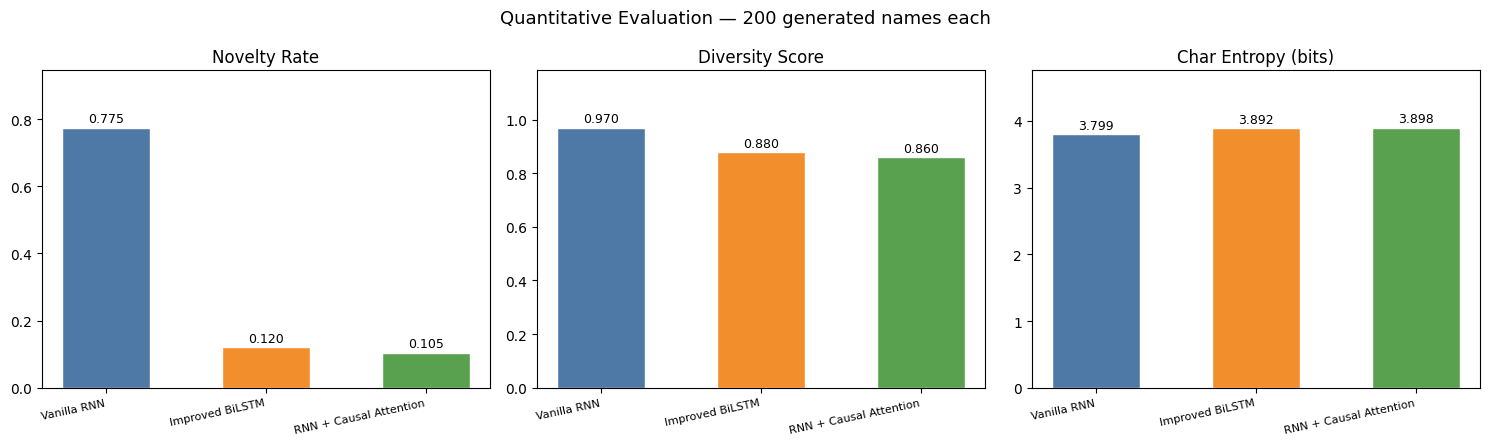

In [ ]:
labels = list(metrics.keys())
colors = ['#4e79a7', '#f28e2b', '#59a14f']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (key, title) in zip(axes, [
        ('novelty',   'Novelty Rate'),
        ('diversity', 'Diversity Score'),
        ('entropy',   'Char Entropy (bits)')]):
    vals = [metrics[l][key] for l in labels]
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', width=0.55)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, max(vals) * 1.22)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.02,
                f'{v:.3f}', ha='center', fontsize=9)
    ax.set_xticklabels(labels, rotation=12, ha='right', fontsize=8)

plt.suptitle(f'Quantitative Evaluation — {N_GEN} generated names each', fontsize=13)
plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
# I am generating bar charts to visually compare the novelty, diversity, and character entropy metrics across all models, providing a clear graphical summary of their performance.

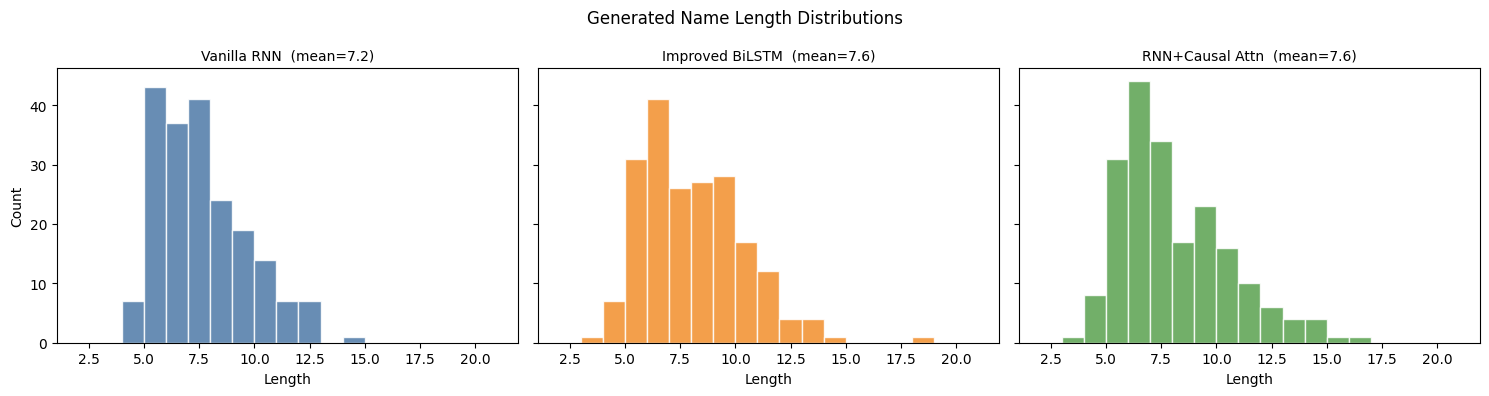

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (label, gen), c in zip(axes,
    [('Vanilla RNN', gen_rnn), ('Improved BiLSTM', gen_blstm),
     ('RNN+Causal Attn', gen_attn)], colors):
    lengths = [len(n) for n in gen]
    ax.hist(lengths, bins=range(2, 22), color=c, edgecolor='white', alpha=0.85)
    ax.set_title(f'{label}  (mean={np.mean(lengths):.1f})', fontsize=10)
    ax.set_xlabel('Length')
axes[0].set_ylabel('Count')
plt.suptitle('Generated Name Length Distributions', fontsize=12)
plt.tight_layout()
plt.savefig('length_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
# I am creating histograms to illustrate the distribution of name lengths for each model's generated output. This plot helps us understand if the models are producing names with realistic or expected lengths compared to the training data.

In [ ]:
for temp, p in [(0.6, 0.80), (0.85, 0.92), (1.1, 0.98)]:
    print(f'\nTemp={temp}  top-p={p}')
    print('-' * 65)
    for label, model, is_a in [
            ('Vanilla RNN',           vanilla_rnn, False),
            ('Improved BiLSTM',        blstm_model, False),
            ('RNN + Causal Attention', attn_rnn,    True)]:
        samples = bulk_generate(model, 12, temp, p, is_a)
        print(f'{label:<26}: {"  ".join(samples)}')
# I am generating and displaying sample names from each model using different temperature and top-p sampling settings. This qualitative analysis helps us understand how these parameters influence the creativity and coherence of the generated names.


Temp=0.6  top-p=0.8
-----------------------------------------------------------------
Vanilla RNN               : Anandar  Kamal  Arun  Manish  Pravish  Ramanind  Anusha  Sundaram  Anindee  Namani  Anusha  Anish
Improved BiLSTM           : Manishankar  Rajendra  Manindra  Shankaracharya  Ramakrishna  Madanlal  Amritesh  Anshuman  Amrik  Anshuman  Rajaraman  Venkataramana
RNN + Causal Attention    : Anupama  Anisha  Shivakumar  Niranjanmurthy  Nagarajan  Muthukumar  Anupama  Aashna  Aman  Shankara  Anushka  Vikrant

Temp=0.85  top-p=0.92
-----------------------------------------------------------------
Vanilla RNN               : Kumareswara  Ajarana  Ardhendra  Arozn  Ashos  Harasedhar  Amit  Pithinisha  Anulad  Manishankar  Amuthi  Anoop
Improved BiLSTM           : Ashish  Shriram  Aaktiy  Aravind  Hafiz  Kumaresan  Palanikumar  Manishankar  Arjunan  Harender  Radha  Arjun
RNN + Causal Attention    : Ankita  Somasundaram  Chandrasekhar  Krishnamoorthy  Nirmal  Vishal  Bheem  Neeraj  

In [ ]:
for label, generated in [('Vanilla RNN',           gen_rnn),
                          ('Improved BiLSTM',        gen_blstm),
                          ('RNN + Causal Attention', gen_attn)]:
    dups      = [n for n in generated if generated.count(n) > 1]
    copies    = [n for n in generated if n.lower() in train_lower]
    too_short = [n for n in generated if len(n) <= 3]
    too_long  = [n for n in generated if len(n) >= 16]
    print(f'\n{label}')
    print(f'  Duplicates       : {len(set(dups))}')
    print(f'  Training copies  : {len(copies)}  {list(set(copies))[:4]}')
    print(f'  Too short (≤3)   : {len(too_short)}')
    print(f'  Too long  (≥16)  : {len(too_long)}')
    # I am conducting a qualitative analysis to identify potential issues in the generated names, such as duplicates, direct copies from the training set, and extreme name lengths (too short or too long).


Vanilla RNN
  Duplicates       : 6
  Training copies  : 45  ['Chandan', 'Kumaresan', 'Krishnanand', 'Bhushan']
  Too short (≤3)   : 0
  Too long  (≥16)  : 0

Improved BiLSTM
  Duplicates       : 21
  Training copies  : 176  ['Srinivasaiah', 'Praveen', 'Muthuraman', 'Geeta']
  Too short (≤3)   : 1
  Too long  (≥16)  : 1

RNN + Causal Attention
  Duplicates       : 25
  Training copies  : 179  ['Parvathishankar', 'Manibhushan', 'Praveen', 'Bhushan']
  Too short (≤3)   : 1
  Too long  (≥16)  : 1


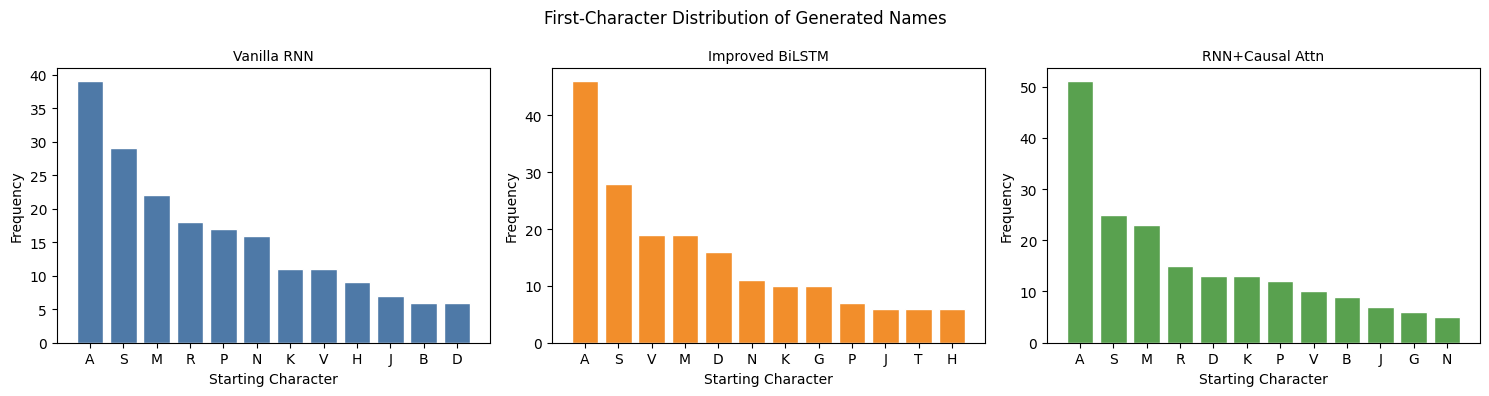

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (label, gen), c in zip(axes,
    [('Vanilla RNN', gen_rnn), ('Improved BiLSTM', gen_blstm),
     ('RNN+Causal Attn', gen_attn)], colors):
    sc = Counter(n[0].upper() for n in gen if n)
    ch, cnt = zip(*sc.most_common(12))
    ax.bar(ch, cnt, color=c, edgecolor='white')
    ax.set_title(f'{label}', fontsize=10)
    ax.set_xlabel('Starting Character')
    ax.set_ylabel('Frequency')
plt.suptitle('First-Character Distribution of Generated Names', fontsize=12)
plt.tight_layout()
plt.savefig('start_char_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
# I am visualizing the distribution of starting characters for the names produced by each model, which can reveal patterns or biases in how the models initiate new names.

In [ ]:
print(f'{labels[0]:<28} {"Params":>10} {"Novelty":>9} {"Diversity":>10} {"AvgLen":>8} {"Entropy":>9}')
print('─' * 76)

all_models = [
    ('Vanilla RNN',           vanilla_rnn, gen_rnn,   history_rnn),
    ('Improved BiLSTM',        blstm_model, gen_blstm, history_blstm),
    ('RNN + Causal Attention', attn_rnn,   gen_attn,  history_attn),
]
summary = {}
for label, model, gen, hist in all_models:
    m = metrics[label]
    print(f'{label:<28} {model.count_parameters():>10,} '
          f'{m["novelty"]:>9.1%} {m["diversity"]:>10.1%} '
          f'{m["avg_len"]:>8.2f} {m["entropy"]:>9.3f}')
    summary[label] = {
        'parameters' : model.count_parameters(),
        'final_loss' : hist[-1],
        'novelty'    : m['novelty'],
        'diversity'  : m['diversity'],
        'avg_len'    : m['avg_len'],
        'entropy'    : m['entropy'],
        'samples'    : gen[:30],
    }

with open('results_summary_v2.json', 'w') as f:
    json.dump(summary, f, indent=2)

for label_short, gen in [('VanillaRNN', gen_rnn),
                           ('BiLSTM',     gen_blstm),
                           ('RNNAttn',    gen_attn)]:
    with open(f'{label_short}.txt', 'w') as f:
        f.write('\n'.join(gen))
    print(f'Saved {len(gen)} names → {label_short}.txt')

print('\nAll outputs saved.')
# I am compiling a final summary that aggregates the model parameters, training loss, and evaluation metrics for all models. Additionally, I am saving this comprehensive summary to a JSON file and storing the generated names in separate text files for future reference.

Vanilla RNN                      Params   Novelty  Diversity   AvgLen   Entropy
────────────────────────────────────────────────────────────────────────────
Vanilla RNN                     222,813     77.5%      97.0%     7.15     3.799
Improved BiLSTM              10,806,138     12.0%      88.0%     7.58     3.892
RNN + Causal Attention        2,414,941     10.5%      86.0%     7.58     3.898
Saved 200 names → VanillaRNN.txt
Saved 200 names → BiLSTM.txt
Saved 200 names → RNNAttn.txt

All outputs saved.
